# E-farsas: spider-level EDA

Fixed sections:
1. Run selection and player evidence
2. Volume, temporal coverage, and quality overview
3. Text-length histograms by original_label and standard_label
4. Category, topic/tag, and temporal distribution
5. Missing fields and invalid dates
6. Cleaning and normalization review
7. NLP with stop-word removal, lemmas, and NER
8. Processed JSONL export


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().resolve().parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Repositorio nao encontrado a partir do diretorio atual.")


REPO_ROOT = _find_repo_root()
for path in (REPO_ROOT, REPO_ROOT / "src", REPO_ROOT / "notebooks"):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import eda_utils as eu

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid", palette="crest")

## Run selection and player evidence

In [2]:
SPIDER = "e_farsas"
PLAYER = "E-farsas"
DATA_DIR = eu.resolve_data_dir(str(REPO_ROOT / "data"))
SNAPSHOT_ID = None
BATCH_SIZE = 64

selection = eu.select_spider_run(DATA_DIR, SPIDER)
profile = eu.get_spider_profile(SPIDER)
display(eu.selection_to_frame(selection))
profile

,spider,agency_id,agency_name,selected_run_id,latest_run_id,latest_valid_run_id,fallback_applied,selection_reason,cleaning_flags,diagnostic_run_ids
0,e_farsas,e_farsas,E-farsas,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,latest_valid_run,"html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix",


SpiderProfile(spider='e_farsas', display_name='E-farsas', analysis_field_order=('title', 'claim', 'summary'), ignored_analysis_titles=frozenset(), dropped_export_titles=frozenset(), extract_label_prefix_before_colon=False, diagnostic_run_ids=(), cleaning_flags=('html_unescape', 'unicode_normalize', 'collapse_whitespace', 'light_encoding_fix'))

In [3]:
runs_df = eu.load_runs_df(DATA_DIR)
spider_runs = runs_df.loc[runs_df["spider"] == SPIDER].sort_values(
    "run_started_at", ascending=False
)
evidence_cols = [
    "run_id",
    "run_started_at",
    "run_finished_at",
    "items_seen",
    "items_stored",
    "items_deduped",
    "items_invalid",
    "has_items_file",
    "is_valid",
]
display(spider_runs[evidence_cols].head(10))

diagnostic_df = eu.diagnostic_runs_df(DATA_DIR, SPIDER)
if not diagnostic_df.empty:
    print("Diagnostic runs configured for this spider:")
    display(diagnostic_df[evidence_cols])

,run_id,run_started_at,run_finished_at,items_seen,items_stored,items_deduped,items_invalid,has_items_file,is_valid
16,20260315T010005Z-1d265f16,2026-03-15 01:00:05+00:00,2026-03-15 07:03:08+00:00,4361,4361,0,0,True,True


## Volume, temporal coverage, and quality overview

In [4]:
nlp = eu.load_nlp_model()
raw_df = eu.load_spider_items_df(DATA_DIR, SPIDER, selection.selected_run_id)
selection, processed_records = eu.build_processed_records(
    DATA_DIR,
    SPIDER,
    selection=selection,
    nlp=nlp,
    batch_size=BATCH_SIZE,
)
processed_df = eu.processed_records_to_df(processed_records)
processed_df["published_at_dt"] = pd.to_datetime(
    processed_df["published_at"], utc=True, errors="coerce"
)

overview = pd.DataFrame(
    [
        {
            "player": PLAYER,
            "selected_run_id": selection.selected_run_id,
            "latest_run_id": selection.latest_run_id,
            "fallback_applied": selection.fallback_applied,
            "raw_rows": len(raw_df),
            "processed_rows": len(processed_df),
            "dropped_rows": len(raw_df) - len(processed_df),
            "coverage_start": processed_df["published_at_dt"].min(),
            "coverage_end": processed_df["published_at_dt"].max(),
            "invalid_dates": int(processed_df["published_at_dt"].isna().sum()),
            "missing_original_label": int(processed_df["original_label"].isna().sum()),
        }
    ]
)
display(overview)
display(raw_df.head(3))
display(processed_df.head(3))

,player,selected_run_id,latest_run_id,fallback_applied,raw_rows,processed_rows,dropped_rows,coverage_start,coverage_end,invalid_dates,missing_original_label
0,E-farsas,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,4361,4361,0,2002-04-01 13:57:32+00:00,2026-03-11 18:11:04+00:00,0,486


,item_id,agency_id,agency_name,spider,source_url,canonical_url,title,published_at,collected_at,claim,summary,verdict,rating,language,country,topics,tags,entities,source_type,run_id,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical
0,4e5517ec6dfd0bd61388e36e802e52dbbafb4fe378922d5ab3c22632531d27ba,e_farsas,E-farsas,e_farsas,https://www.e-farsas.com/alexandre-de-moraes-determinou-que-o-criador-das-urnas-eletronicas-esta-foragido.html,http://www.e-farsas.com/alexandre-de-moraes-determinou-que-o-criador-das-urnas-eletronicas-esta-foragido.html,Alexandre de Moraes determinou que o criador das urnas eletrônicas está foragido?,2025-12-29T14:17:45+00:00,2026-03-15T01:47:36+00:00,Alexandre de Moraes determinou que o criador das urnas eletrônicas está foragido?,"Ministro do STF teria expedido mandado de prisão contra o criador das urnas eletrônicas que, a partir de agora, é considerado foragido da justiça! Será?",Falso,Falso,pt-BR,BR,"[Conspirações, Política]","[Alexandre de Moraes, criador, determinou, falso, Foragido, inventor, mentira, STF, urnas eletrônicas]",[],Article,20260315T010005Z-1d265f16,2025-12-29 14:17:45+00:00,2026-03-15 01:47:36+00:00,1811.497500,81,81,152,www.e-farsas.com,0.0
1,0ce108403eac3615f7a8dd459cad0dab40bb3fbfbf7023d778402d1ac7260ade,e_farsas,E-farsas,e_farsas,https://www.e-farsas.com/as-previsoes-dos-videntes-que-falharam-em-2025.html,http://www.e-farsas.com/as-previsoes-dos-videntes-que-falharam-em-2025.html,As previsões dos videntes que falharam em 2025!,2025-12-30T14:58:08+00:00,2026-03-15T01:47:36+00:00,As previsões dos videntes que falharam em 2025!,Investigamos as previsões dos maiores videntes do Brasil e comprovamos que eles mais erram do que acertam. Confira aqui no E-farsas!,Falso,Falso,pt-BR,BR,[Retrospectiva],"[2025, Carlinhos Vidente, Chaline Grazik, falharam, falso, Jucelino da Luz, Marcia Sensitiva, picaretas, previsões, Robério de Ogum, videntes]",[],Article,20260315T010005Z-1d265f16,2025-12-30 14:58:08+00:00,2026-03-15 01:47:36+00:00,1786.824444,47,47,132,www.e-farsas.com,0.0
2,8521566c553004106e36d6e9df50d9f5542fef7d93f33329bad125c0ac9ea8c4,e_farsas,E-farsas,e_farsas,https://www.e-farsas.com/a-lista-de-pessoas-que-morreram-por-saber-demais-e-verdadeira.html,http://www.e-farsas.com/a-lista-de-pessoas-que-morreram-por-saber-demais-e-verdadeira.html,A lista de pessoas que “morreram por saber demais” é verdadeira?,2025-12-11T17:58:16+00:00,2026-03-15T01:47:36+00:00,A lista de pessoas que “morreram por saber demais” é verdadeira?,"Vídeo mostra inventores e pesquisadores que teriam morrido de forma misteriosa após descobertas revolucionárias, como a cura para o câncer! Será verdade?",Falso,Falso,pt-BR,BR,[Conspirações],"[aids, cancer, conspiração, demais” é verdadeira, fake, lista, morreram, pessoas, saber]",[],Article,20260315T010005Z-1d265f16,2025-12-11 17:58:16+00:00,2026-03-15 01:47:36+00:00,2239.822222,64,64,153,www.e-farsas.com,0.0


,record_id,source_record_id,dataset_id,source_url,published_at,language,title,author,subtitle,claim_text,body_text,analysis_text,text_for_ner,text_without_stopwords,lemmatized_text,original_label,standard_label,category,entities,variant,metadata.analysis_text_length,metadata.entity_count,metadata.spider,metadata.agency_id,metadata.agency_name,metadata.run_id,metadata.latest_run_id,metadata.fallback_applied,metadata.source_type,metadata.source_topics,metadata.source_tags,metadata.source_rating,published_at_dt
0,factcheck_scrape_e_farsas:4e5517ec6dfd0bd61388e36e802e52dbbafb4fe378922d5ab3c22632531d27ba,4e5517ec6dfd0bd61388e36e802e52dbbafb4fe378922d5ab3c22632531d27ba,factcheck_scrape_e_farsas,https://www.e-farsas.com/alexandre-de-moraes-determinou-que-o-criador-das-urnas-eletronicas-esta-foragido.html,2025-12-29T14:17:45+00:00,pt-BR,Alexandre de Moraes determinou que o criador das urnas eletrônicas está foragido?,None,None,Alexandre de Moraes determinou que o criador das urnas eletrônicas está foragido?,"Ministro do STF teria expedido mandado de prisão contra o criador das urnas eletrônicas que, a partir de agora, é considerado foragido da justiça! Será?",alexandre de moraes determinou que o criador das urnas eletrônicas está foragido? ministro do stf teria expedido mandado de prisão contra o criador das urna...,alexandre de moraes determinou que o criador das urnas eletrônicas está foragido? ministro do stf teria expedido mandado de prisão contra o criador das urna...,alexandre moraes determinou criador urnas eletrônicas foragido ministro stf teria expedido mandado prisão criador urnas eletrônicas considerado foragido jus...,alexandre de moraes determinar que o criador de o urna eletrônico estar foragido ministro de o stf ter expeder mandar de prisão contra o criador de o urna e...,Falso,false,Conspirações,"[{'text': 'alexandre de moraes', 'label': 'PER', 'start_char': 0, 'end_char': 19}, {'text': 'stf', 'label': 'LOC', 'start_char': 94, 'end_char': 97}]",claim_summary,234,2,e_farsas,e_farsas,E-farsas,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,Article,"[Conspirações, Política]","[Alexandre de Moraes, criador, determinou, falso, Foragido, inventor, mentira, STF, urnas eletrônicas]",Falso,2025-12-29 14:17:45+00:00
1,factcheck_scrape_e_farsas:0ce108403eac3615f7a8dd459cad0dab40bb3fbfbf7023d778402d1ac7260ade,0ce108403eac3615f7a8dd459cad0dab40bb3fbfbf7023d778402d1ac7260ade,factcheck_scrape_e_farsas,https://www.e-farsas.com/as-previsoes-dos-videntes-que-falharam-em-2025.html,2025-12-30T14:58:08+00:00,pt-BR,As previsões dos videntes que falharam em 2025!,None,None,As previsões dos videntes que falharam em 2025!,Investigamos as previsões dos maiores videntes do Brasil e comprovamos que eles mais erram do que acertam. Confira aqui no E-farsas!,as previsões dos videntes que falharam em 2025! investigamos as previsões dos maiores videntes do brasil e comprovamos que eles mais erram do que acertam. c...,as previsões dos videntes que falharam em 2025! investigamos as previsões dos maiores videntes do brasil e comprovamos que eles mais erram do que acertam. c...,previsões videntes falharam 2025 investigamos previsões maiores videntes brasil comprovamos erram acertam confira e-farsas,o previsão de o vidente que falhar em 2025 investigar o previsão de o grande vidente de o brasil e comprovar que eles mais errar de o que acertar confira aq...,Falso,false,Retrospectiva,"[{'text': 'brasil', 'label': 'LOC', 'start_char': 98, 'end_char': 104}]",claim_summary,180,1,e_farsas,e_farsas,E-farsas,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,Article,[Retrospectiva],"[2025, Carlinhos Vidente, Chaline Grazik, falharam, falso, Jucelino da Luz, Marcia Sensitiva, picaretas, previsões, Robério de Ogum, videntes]",Falso,2025-12-30 14:58:08+00:00
2,factcheck_scrape_e_farsas:8521566c553004106e36d6e9df50d9f5542fef7d93f33329bad125c0ac9ea8c4,8521566c553004106e36d6e9df50d9f5542fef7d93f33329bad125c0ac9ea8c4,factcheck_scrape_e_farsas,https://www

## Text-length histograms by label

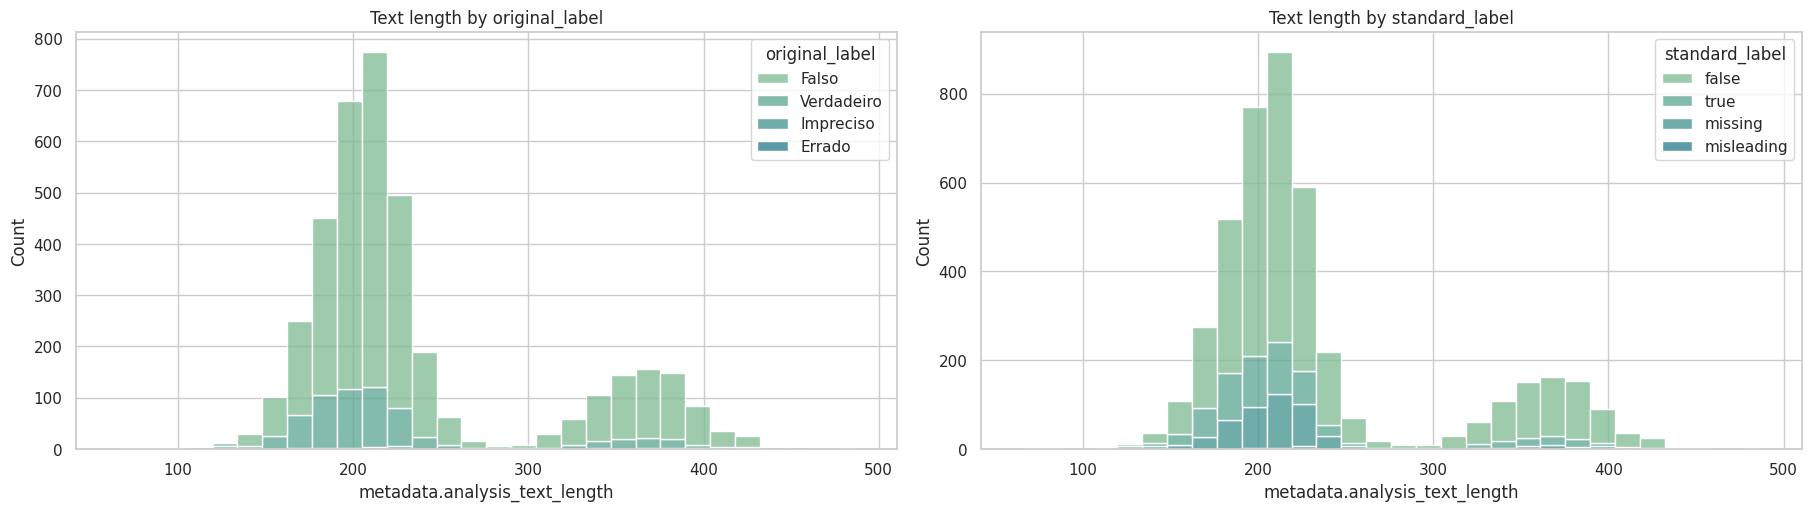

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
sns.histplot(
    data=processed_df,
    x="metadata.analysis_text_length",
    hue="original_label",
    bins=30,
    multiple="stack",
    ax=axes[0],
)
axes[0].set_title("Text length by original_label")

sns.histplot(
    data=processed_df,
    x="metadata.analysis_text_length",
    hue="standard_label",
    bins=30,
    multiple="stack",
    ax=axes[1],
)
axes[1].set_title("Text length by standard_label")
plt.show()

## Category, topic/tag, temporal distribution, and data quality

In [6]:
topic_counts = raw_df["topics"].explode().dropna().value_counts().head(20)
tag_counts = raw_df["tags"].explode().dropna().value_counts().head(20)
category_counts = processed_df["category"].value_counts(dropna=False).head(20)

display(category_counts.rename_axis("category").reset_index(name="count"))
display(topic_counts.rename_axis("topic").reset_index(name="count"))
display(tag_counts.rename_axis("tag").reset_index(name="count"))

monthly = (
    processed_df.dropna(subset=["published_at_dt"])
    .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")
    .size()
    .reset_index(name="count")
)
display(monthly.tail(24))

missing_fields = (
    raw_df[["title", "claim", "summary", "verdict", "rating", "published_at"]]
    .isna()
    .sum()
    .rename_axis("field")
    .reset_index(name="missing_count")
)
display(missing_fields)

display(
    processed_df.loc[
        processed_df["published_at_dt"].isna(), ["source_record_id", "title", "published_at"]
    ].head(20)
)

,category,count
0,Conspirações,603
1,Crimes,371
2,Cinema / TV,338
3,Animais,333
4,Acidentes,261
5,Política,229
6,E-farsas,168
7,E-farsas TV,160
8,Humor,146
9,Saúde,143


,topic,count
0,Viral,727
1,Política,710
2,Conspirações,674
3,Saúde,536
4,Crimes,528
5,Fotos,407
6,Humor,373
7,Cinema / TV,362
8,Animais,353
9,Montagens,321


,tag,count
0,falso,1268
1,farsa,814
2,mentira,633
3,fake,608
4,montagem,404
5,video,380
6,boato,351
7,viral,322
8,verdade,310
9,hoax,291


/tmp/ipykernel_2046284/1119197242.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())


,month,count
225,2024-04-01,11
226,2024-05-01,11
227,2024-06-01,19
228,2024-07-01,23
229,2024-08-01,24
230,2024-09-01,19
231,2024-10-01,22
232,2024-11-01,14
233,2024-12-01,14
234,2025-01-01,21


,field,missing_count
0,title,0
1,claim,0
2,summary,0
3,verdict,486
4,rating,486
5,published_at,0


,source_record_id,title,published_at


## Cleaning and normalization review

In [7]:
comparison = raw_df.rename(
    columns={
        "item_id": "source_record_id",
        "title": "raw_title",
        "claim": "raw_claim",
        "summary": "raw_summary",
        "published_at": "raw_published_at",
        "verdict": "raw_verdict",
    }
).merge(
    processed_df[
        [
            "source_record_id",
            "title",
            "claim_text",
            "body_text",
            "analysis_text",
            "original_label",
            "standard_label",
            "published_at",
        ]
    ],
    on="source_record_id",
    how="left",
)
display(comparison.head(15))

,source_record_id,agency_id,agency_name,spider,source_url,canonical_url,raw_title,raw_published_at,collected_at,raw_claim,raw_summary,raw_verdict,rating,language,country,topics,tags,entities,source_type,run_id,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical,title,claim_text,body_text,analysis_text,original_label,standard_label,published_at
0,4e5517ec6dfd0bd61388e36e802e52dbbafb4fe378922d5ab3c22632531d27ba,e_farsas,E-farsas,e_farsas,https://www.e-farsas.com/alexandre-de-moraes-determinou-que-o-criador-das-urnas-eletronicas-esta-foragido.html,http://www.e-farsas.com/alexandre-de-moraes-determinou-que-o-criador-das-urnas-eletronicas-esta-foragido.html,Alexandre de Moraes determinou que o criador das urnas eletrônicas está foragido?,2025-12-29T14:17:45+00:00,2026-03-15T01:47:36+00:00,Alexandre de Moraes determinou que o criador das urnas eletrônicas está foragido?,"Ministro do STF teria expedido mandado de prisão contra o criador das urnas eletrônicas que, a partir de agora, é considerado foragido da justiça! Será?",Falso,Falso,pt-BR,BR,"[Conspirações, Política]","[Alexandre de Moraes, criador, determinou, falso, Foragido, inventor, mentira, STF, urnas eletrônicas]",[],Article,20260315T010005Z-1d265f16,2025-12-29 14:17:45+00:00,2026-03-15 01:47:36+00:00,1811.497500,81,81,152,www.e-farsas.com,0.0,Alexandre de Moraes determinou que o criador das urnas eletrônicas está foragido?,Alexandre de Moraes determinou que o criador das urnas eletrônicas está foragido?,"Ministro do STF teria expedido mandado de prisão contra o criador das urnas eletrônicas que, a partir de agora, é considerado foragido da justiça! Será?",alexandre de moraes determinou que o criador das urnas eletrônicas está foragido? ministro do stf teria expedido mandado de prisão contra o criador das urna...,Falso,false,2025-12-29T14:17:45+00:00
1,0ce108403eac3615f7a8dd459cad0dab40bb3fbfbf7023d778402d1ac7260ade,e_farsas,E-farsas,e_farsas,https://www.e-farsas.com/as-previsoes-dos-videntes-que-falharam-em-2025.html,http://www.e-farsas.com/as-previsoes-dos-videntes-que-falharam-em-2025.html,As previsões dos videntes que falharam em 2025!,2025-12-30T14:58:08+00:00,2026-03-15T01:47:36+00:00,As previsões dos videntes que falharam em 2025!,Investigamos as previsões dos maiores videntes do Brasil e comprovamos que eles mais erram do que acertam. Confira aqui no E-farsas!,Falso,Falso,pt-BR,BR,[Retrospectiva],"[2025, Carlinhos Vidente, Chaline Grazik, falharam, falso, Jucelino da Luz, Marcia Sensitiva, picaretas, previsões, Robério de Ogum, videntes]",[],Article,20260315T010005Z-1d265f16,2025-12-30 14:58:08+00:00,2026-03-15 01:47:36+00:00,1786.824444,47,47,132,www.e-farsas.com,0.0,As previsões dos videntes que falharam em 2025!,As previsões dos videntes que falharam em 2025!,Investigamos as previsões dos maiores videntes do Brasil e comprovamos que eles mais erram do que acertam. Confira aqui no E-farsas!,as previsões dos videntes que falharam em 2025! investigamos as previsões dos maiores videntes do brasil e comprovamos que eles mais erram do que acertam. c...,Falso,false,2025-12-30T14:58:08+00:00
2,8521566c553004106e36d6e9df50d9f5542fef7d93f33329bad125c0ac9ea8c4,e_farsas,E-farsas,e_farsas,https://www.e-farsas.com/a-lista-de-pessoas-que-morreram-por-saber-demais-e-verdadeira.html,http://www.e-farsas.com/a-lista-de-pessoas-que-morreram-por-saber-demais-e-verdadeira.html,A lista de pessoas que “morreram por saber demais” é verdadeira?,2025-12-11T17:58:16+00:00,2026-03-15T01:47:36+00:00,A lista de pessoas que “morreram por saber demais” é verdadeira?,"Vídeo mostra inventores e pesquisadores que teriam morrido de forma misteriosa após descobertas revolucionárias, como a cura para o câncer! Será verdade?",Falso,Falso,pt-BR,BR,[Conspirações],"[aids, cancer, conspiração, demais” é verdadeira, fake, lista, morreram, pessoas, saber]",[],Article,20260315T010005Z-1d265f16,2025-12-11 17:58:16+00:00,2026-03-15 01:47:36+00:00,2239.

## NLP outputs

In [8]:
lemma_counts = (
    processed_df["lemmatized_text"].str.split().explode().dropna().value_counts().head(20)
)
display(lemma_counts.rename_axis("lemma").reset_index(name="count"))

entity_series = processed_df["entities"].explode().dropna()
if entity_series.empty:
    entity_df = pd.DataFrame(columns=["text", "label", "start_char", "end_char"])
else:
    entity_df = pd.json_normalize(entity_series)

display(entity_df.head(20))
display(entity_df["label"].value_counts().rename_axis("label").reset_index(name="count"))
display(processed_df[["source_record_id", "text_without_stopwords", "lemmatized_text"]].head(10))

,lemma,count
0,o,24263
1,de,14987
2,ser,8317
3,em,7950
4,que,6694
5,um,6211
6,verdade,3207
7,e,2423
8,a,1957
9,por,1851


,text,label,start_char,end_char
0,alexandre de moraes,PER,0,19
0,stf,LOC,94,97
1,brasil,LOC,98,104
4,pernalonga,LOC,2,12
4,pernalonga,LOC,83,93
5,jeffrey epstein,PER,12,27
5,britney spears,MISC,42,56
5,britney spears,MISC,141,155
6,lula,PER,47,51
6,niterói wallace,PER,128,143


,label,count
0,PER,3324
1,LOC,3116
2,MISC,1442
3,ORG,870


,source_record_id,text_without_stopwords,lemmatized_text
0,4e5517ec6dfd0bd61388e36e802e52dbbafb4fe378922d5ab3c22632531d27ba,alexandre moraes determinou criador urnas eletrônicas foragido ministro stf teria expedido mandado prisão criador urnas eletrônicas considerado foragido jus...,alexandre de moraes determinar que o criador de o urna eletrônico estar foragido ministro de o stf ter expeder mandar de prisão contra o criador de o urna e...
1,0ce108403eac3615f7a8dd459cad0dab40bb3fbfbf7023d778402d1ac7260ade,previsões videntes falharam 2025 investigamos previsões maiores videntes brasil comprovamos erram acertam confira e-farsas,o previsão de o vidente que falhar em 2025 investigar o previsão de o grande vidente de o brasil e comprovar que eles mais errar de o que acertar confira aq...
2,8521566c553004106e36d6e9df50d9f5542fef7d93f33329bad125c0ac9ea8c4,lista pessoas morreram verdadeira vídeo mostra inventores pesquisadores teriam morrido misteriosa descobertas revolucionárias cura câncer será verdade,o lista de pessoa que morrer por saber demais ser verdadeiro vídeo mostrar inventor e pesquisador que ter morrer de forma misterioso após descobrir revoluci...
3,75541908f020e1aa883729163ee2e0b8d348bb90a99241cd46a9e95839aac8c2,8 janeiro 3 anos tentativa golpe aconteceu tentativa golpe dia 8 janeiro 2023 hoje quantos criminosos presos detalhes,8 de janeiro 3 ano de o tentativa de golpe de estado o que acontecer desde o tentativa de golpe de estado em o dia 8 de janeiro de 2023 até hoje quanto crim...
4,db4352bb6724c6251c92e156fe3ed83121bc2ef4c14dc74f49c89980081247d1,pernalonga inspirado serial killer apelidado coelho personagem pernalonga teria sido inspirado serial killer coelho adorava cenoura jogava vítimas janela,o pernalonga ser inspirar em um serial killer apelidar de coelho o personagem pernalongo ter ser inspirar em um serial killer conhecer como coelho que adora...
5,9eebc00d08f933d07c91a7f29a42733772985e86a51d361bc2ff6c947fb8ea32,arquivos jeffrey epstein mostraram britney spears clonada documentos pedófilo norte-americano teriam confirmado cantora britney spears clonada clone atualme...,arquivo de jeffrey epstein mostrar que britneyr spears ser clonar documento de o pedófilo norte-americano ter confirmar que o cantora britney spears ser clo...
6,4eff49414c8c051ac191e88286f0372e17bb03e915f01b29334bdadff975b2b0,presidente escola samba homenageou lula réu morte criança verdade presidente acadêmicos niterói wallace palhares responde justiça morte menina 11 anos,o presidente de o escola de samba que homenagear lula ser réu por morte de um criança ser verdade que o presidente de o acadêmico de niterói wallace palhar ...
7,d31d5df92726aac45f00bee4639c4548a27eebc8a2b6af20f16a4459460308e4,existe vídeo youtube 140 anos duração vídeo século duração teria sido publicado youtube teria alcançado 2 milhões visualizações será verdade,existir mesmo um vídeo em o youtube com 140 ano de duração vídeo com mais de um século de duração ter ser publicar em o youtube e já ter alcançar mais de 2 ...
8,ff0b4c54c00389821349c13274e22b0f8ae5c53b44d8f2aa44e792dbe35bdb3f,fenômeno miraclein fevereiro 2026 acontece 823 anos verdade fevereiro 2026 terá exatamente 4 dia semana fenômeno raro repetir daqui 823 anos,fenômeno miraclein em fevereiro de 2026 só acontecer a cada 823 ano ser verdade que o mês de fevereiro de 2026 ter exatamente 4 de cada dia de o semana e es...
9,d3fc23838c27c2473338b99a62168d507a6798abce477fbb6294b7801f089df3,caso havaianas há trás campanhas boicote online propaganda entrar 2026 pé direito havaianas atraiu si milhares perfis raivosos há trás boicote,caso havaiano o que haver por trás de o campanha de boicote online a o dizer em propaganda para não entrar 2026 com o pé direito a havaiana atrair para se m...


## Export processed JSONL

In [9]:
export_info = eu.export_processed_records(
    DATA_DIR,
    SPIDER,
    records=processed_records,
    selection=selection,
    snapshot_id=SNAPSHOT_ID,
)

display(
    pd.DataFrame(
        [
            {
                "snapshot_id": export_info["snapshot_id"],
                "record_count": export_info["record_count"],
                "spider_path": str(export_info["spider_path"]),
                "combined_path": str(export_info["combined_path"]),
                "manifest_path": str(export_info["manifest_path"]),
            }
        ]
    )
)

,snapshot_id,record_count,spider_path,combined_path,manifest_path
0,20260315T231910Z-e_farsas,4361,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T231910Z-e_farsas/spiders/e_farsas.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T231910Z-e_farsas/factcheck_scrape_unified.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T231910Z-e_farsas/manifest.json
